# WT across experiments — temporal-profile correlation of hme1_1, hme1_2 and hme1_diaPASEF

Do the three wild-type hTERT-HME1 experiments tell the same story about the EGF response? Each dataset is
reduced to a **sites × timepoints matrix of WT `log2:FC` vs starve** at the timepoints all three share, and
the matrices are compared on the sites all three quantified.

| dataset | platform | EGF dose | timepoints (min) |
|---|---|---|---|
| hme1_1 | TMT, DDA | 4.7 nM | 1, 2, 5, 10, 90 |
| hme1_2 | TMT, DDA | 1.57 nM | 2, 5, 10, 15, 90 |
| hme1_diaPASEF | LFQ, diaPASEF | 0.157 nM | 2, 5, 10, 15, 20, 30, 90 |

Shared: **2, 5, 10, 90 min**, EGF only, since diaPASEF has no INS arm. Any disagreement is therefore a mix
of platform (TMT ratio compression, DDA vs DIA), a **30-fold dose range**, culture batch and FC
normalisation, and this notebook cannot separate those. hme1_1 vs hme1_2 is the closest pair
(same platform, 3× dose).

**Site matching.** The `site` string is not usable across datasets: it embeds peptide start/end
positions, which differ between the hme1_1 and hme1_2 database versions for ~3% of shared peptides, and
diaPASEF sequences carry UniMod tags (`C(UniMod:4)`, `(UniMod:1)`) that TMT sequences do not.
`site_match_key(key="peptide")` uses **protein accession + UniMod-free phosphopeptide sequence** (phospho
residues lowercase), and only **fully localized** sites are kept (`fully_localized_mask`). Duplicate keys
keep the row with the fewest missing profile values (`deduplicate_by_key`). `KEY = "phosphosite"`
(accession + residue positions) pools different peptides carrying the same site, which gives more
matches.

**Site selection.** Only sites present in **all three** datasets. For diaPASEF, the WT site must also
have **≥ 1 replicate at every timepoint used** (the shared timepoints plus starve). The TMT tables have
no missing FC values.

The three summaries, the uncentered per-site r and the shuffled-site null are the same as in
`diaPASEF_profile_correlation.ipynb`, and are explained there.

**Centring matters much more here than within diaPASEF.** Each dataset carries its own shift shared by
all sites (no FC normalisation in any of the three tables): diaPASEF sits at −0.2 to −0.8, hme1_2 at up to
+0.3, hme1_1 at −0.1 to −0.4. Uncentred, the per-site r mostly measures whether two datasets happen to
share that shift (checked 2026-09-16: hme1_1 vs hme1_2 median per-site r −0.40, with a shuffled-site
null of −0.51). `CENTER = "median"` (default) removes each timepoint's median over the shared sites,
per dataset, *after* the shared site set is fixed. Section 6 shows the uncentred run. One
caveat is specific to this notebook: **with 4 timepoints, a per-site r has almost no degrees of
freedom**, so only the distributions and the difference from the null carry information.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..",),)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT,)

from src.QC import (subset_by_coverage,
                    site_match_key,
                    fully_localized_mask,
                    deduplicate_by_key,
                    common_timepoints,
                    profile_matrix,
                    align_profiles,
                    global_profile_correlation,
                    per_site_profile_correlation,
                    summarise_per_site_correlation,
                    per_timepoint_correlation,
                    plot_correlation_heatmap,
                    plot_per_site_distributions,
                    plot_per_timepoint_correlation,
                    plot_profile_scatter_grid,
                    venn_diagrams,)
from src.filters import filter_by_ffdr

## Parameters

In [2]:
DIA_DIR = "../../Experiment/hme1_diaPASEF/Data/Processed/"
FILES = {"hme1_1": "../../Experiment/hme1_1/Data/Processed/20260807_hTERT_HEM1_1_processed_phPlus.tsv",
         "hme1_2": "../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv",
         "diaPASEF": DIA_DIR + "20260818_peptide_MS2quant_None_transformed_limma_phPlus.tsv",}
DIA_BATCH_CORRECTED_FILE = DIA_DIR + "20260824_peptide_MS2quant_None_batchCorrected_transformed_limma_phPlus.tsv"
USE_DIA_BATCH_CORRECTED = True   # diaPASEF profile values from the batch-corrected table (site + FFDR stay from the uncorrected one)

CELL_LINE = "WT"
CONDITION = "EGF"
DATA_TYPE = "log2:FC"
KEY = "peptide"                  # "peptide" | "phosphosite" | "site"  (see site_match_key)
LOCALIZED_ONLY = True
MIN_REPS_DIA = 1                 # diaPASEF: >= 1 replicate at every used timepoint (incl. starve)

CENTER = "median"                # None | "median" — per dataset, per timepoint, over the shared sites (see section 6)
PER_SITE_METHOD = "uncentered"
GLOBAL_METHOD = "pearson"
MAX_FFDR = 0.05                  # responsive subset; None skips it
RESPONSIVE_IN = ["hme1_1", "hme1_2", "diaPASEF"]   # union: responsive in at least one of these

SAVE_DIR = f"Results/{pd.Timestamp.today():%Y%m%d}_QC_WT_datasets_profile_correlation_files/"
def out(name):
    return None if SAVE_DIR is None else os.path.join(SAVE_DIR, name,)

## Load

In [3]:
ffdr_col = f"{CELL_LINE}_log2:FFDR_{CONDITION}_omnibus"

def wanted(col):
    parts = col.split("_")
    return (col in ("site", "protein_Id", "protein_name", "peptide_index", ffdr_col,)
            or (len(parts) >= 4 and parts[0] == CELL_LINE and parts[2] == CONDITION
                and parts[1] in ("raw:abs", "raw:mean", DATA_TYPE,)))

dfs = {name: pd.read_csv(path, sep="\t", usecols=wanted, low_memory=False,) for name, path in FILES.items()}

if USE_DIA_BATCH_CORRECTED:
    # Values from the batch-corrected table; 'site' (with lowercase phospho residues) and the limma FFDR
    # from the uncorrected one. peptide_index is unique in both.
    corrected = pd.read_csv(DIA_BATCH_CORRECTED_FILE, sep="\t",
                            usecols=lambda c: wanted(c) and c not in ("site", ffdr_col,), low_memory=False,)
    dfs["diaPASEF"] = corrected.merge(dfs["diaPASEF"][["peptide_index", "site", ffdr_col]],
                                      on="peptide_index", how="left", validate="one_to_one",)

for name, df in dfs.items():
    print(f"{name:9s} {len(df):6d} rows, {df.shape[1]:3d} columns")

hme1_1     35002 rows,  46 columns
hme1_2     50002 rows,  47 columns
diaPASEF   71087 rows,  50 columns


## Shared timepoints and the diaPASEF coverage requirement

In [4]:
TIMEPOINTS = common_timepoints(dfs,
                               cell_lines=CELL_LINE,
                               condition=CONDITION,
                               data_type=DATA_TYPE,)
print(f"shared timepoints: {TIMEPOINTS}")

dfs_sel = dict(dfs)
dfs_sel["diaPASEF"] = subset_by_coverage(dfs["diaPASEF"],
                                         cell_lines=[CELL_LINE],
                                         min_reps=MIN_REPS_DIA,
                                         conditions=[f"_{CONDITION}_"],
                                         data_type="raw:abs",
                                         timepoints=TIMEPOINTS + ["starve"],
                                         group_label=f"diaPASEF {CELL_LINE}",)

shared timepoints: ['2', '5', '10', '90']
diaPASEF WT: 28812 of 71087 sites covered in >= 1 replicate(s) at every timepoint (40.5%)


## Match keys — localized sites, one row per key

,dataset,rows_in,localized,duplicates_dropped,unique_keys
0,hme1_1,35002,22010,0,22010
1,hme1_2,50002,33439,0,33439
2,diaPASEF,28812,21793,0,21793


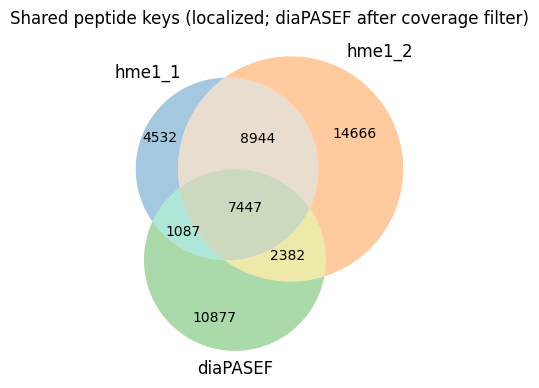

In [5]:
keyed = {}
rows = []
for name, df in dfs_sel.items():
    n0 = len(df)
    if LOCALIZED_ONLY:
        df = df.loc[fully_localized_mask(df)]
    n_loc = len(df)
    profile_cols = [c for c in df.columns if c.split("_")[1:2] == [DATA_TYPE] and c.split("_")[3] in TIMEPOINTS]
    intensity_cols = [c for c in df.columns if c.split("_")[1:2] == ["raw:mean"]]
    dedup, n_dup = deduplicate_by_key(df,
                                      key=site_match_key(df, key=KEY,),
                                      profile_cols=profile_cols,
                                      intensity_cols=intensity_cols,)
    keyed[name] = dedup
    rows.append({"dataset": name, "rows_in": n0, "localized": n_loc,
                 "duplicates_dropped": n_dup, "unique_keys": len(dedup)})
display(pd.DataFrame(rows))

venn_diagrams([d.reset_index() for d in keyed.values()],
              labels=list(keyed),
              colors=["tab:blue", "tab:orange", "tab:green"],
              title=f"Shared {KEY} keys (localized; diaPASEF after coverage filter)",
              column_to_compare="match_key",);

## Profiles on the shared sites

In [6]:
# Align first (fixes the shared site set), centre afterwards, so the medians are taken over the same sites
profiles_raw = align_profiles({name: profile_matrix(df,
                                                    cell_line=CELL_LINE,
                                                    condition=CONDITION,
                                                    data_type=DATA_TYPE,
                                                    timepoints=TIMEPOINTS,)
                               for name, df in keyed.items()})
profiles_centred = {n: m - m.median() for n, m in profiles_raw.items()}  # = profile_matrix(center="median") on these rows
profiles = profiles_centred if CENTER == "median" else profiles_raw
N_SHARED = len(profiles["hme1_2"])
print(f"{N_SHARED} sites shared by all three datasets with a complete profile at {TIMEPOINTS}")
display(pd.DataFrame({n: m.median() for n, m in profiles_raw.items()}).T.round(3).rename_axis("median log2:FC (uncentred)"))
display(pd.DataFrame({n: m.abs().quantile(0.95) for n, m in profiles_raw.items()}).T.round(3).rename_axis("95th pct |log2:FC|"))

7447 sites shared by all three datasets with a complete profile at ['2', '5', '10', '90']


,2,5,10,90
median log2:FC (uncentred),,,,
hme1_1,-0.204,-0.136,-0.370,-0.282
hme1_2,-0.016,0.293,0.191,0.097
diaPASEF,-0.212,-0.471,-0.569,-0.773


,2,5,10,90
95th pct |log2:FC|,,,,
hme1_1,0.647,0.938,1.072,0.780
hme1_2,0.406,0.809,0.911,0.688
diaPASEF,1.002,1.621,1.606,1.859


## 1. Global correlation

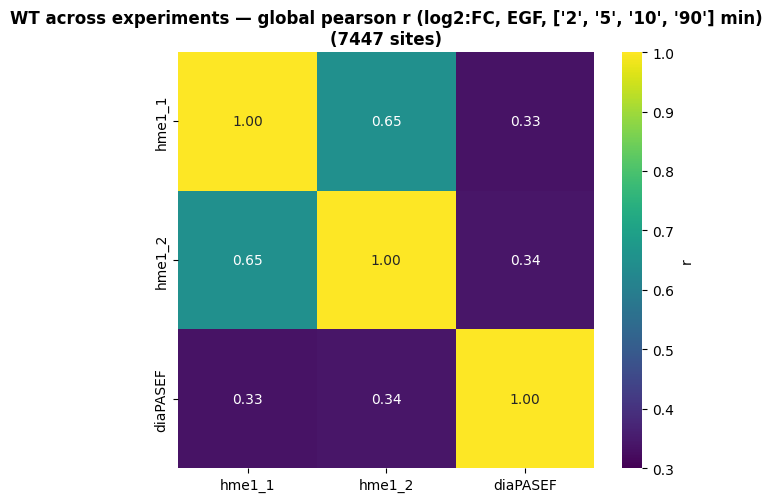

,hme1_1,hme1_2,diaPASEF
hme1_1,1.000,0.648,0.334
hme1_2,0.648,1.000,0.340
diaPASEF,0.334,0.340,1.000


In [7]:
global_r = global_profile_correlation(profiles,
                                      method=GLOBAL_METHOD,)
plot_correlation_heatmap(global_r,
                         title=f"WT across experiments — global {GLOBAL_METHOD} r ({DATA_TYPE}, {CONDITION}, {TIMEPOINTS} min)",
                         cluster=False,
                         figsize=(6, 5),
                         save_path=out("01_global_correlation_heatmap.png"),)
global_r.round(3)

## 2. Per-site correlation, with the shuffled-site chance level

In every pair (for example `hme1_1 vs hme1_2`), the first name is the dataset kept in place and the
second is the one whose rows are shuffled for the chance level.

### What a per-site correlation is

Take **one site** and look at its profile in two datasets: 4 `log2:FC` values each (one per
timepoint). Those two short vectors give **one correlation coefficient r** for that site. It asks:
*does this site go up and down at the same times in both datasets?* Doing this for every site gives
thousands of r values, one per site, and the violin plot shows their distribution.

A made-up example with 7 timepoints (the idea is identical with the 4 shared timepoints used here, 2, 5, 10 and 90 min):

| profile | 2 | 5 | 10 | 15 | 20 | 30 | 90 | r vs site A in the first dataset |
|---|---|---|---|---|---|---|---|---|
| site A, the first dataset | 0.2 | 1.5 | 1.2 | 0.8 | 0.5 | 0.3 | 0.1 | — |
| site A, second dataset (same shape) | 0.1 | 1.2 | 1.4 | 0.9 | 0.4 | 0.2 | 0.0 | **+0.98** |
| site A, second dataset (mirror image: goes down instead of up) | −0.2 | −1.3 | −1.1 | −0.7 | −0.4 | −0.3 | 0.0 | **≈ −1** |
| a site with an unrelated profile | −0.3 | −0.1 | 0.4 | −0.6 | 0.2 | 0.5 | −0.2 | **+0.01** |

- **r near +1:** same shape. **r near −1:** opposite direction. **r near 0:** unrelated.
- The coefficient is *uncentered* (cosine similarity), so the direction relative to the starve
  baseline (0) counts. The size of the response does not: a site that rises to +3 in one dataset and
  to +0.5 in the other, with the same shape, still gets r ≈ +1. Amplitude is what the global r
  (section 1) captures.
- **One site's r means very little on its own.** With only 4 points, 1 in 20 pairs of
  unrelated random profiles already reaches r ≈ 0.8, so never read a single site. Read the *distribution*, and
  compare it with a chance level.

### What the shuffled-site chance level is

The question is: *how high would the per-site r be if the two datasets had nothing in common site by
site?* To answer it, the function keeps the the first dataset profiles as they are and **shuffles the rows
of the other dataset**. Site A in the first dataset is then compared with, say, site B in the other dataset;
site B with site K; and so on. This is `per_site_profile_correlation(..., shuffle=True)`.

These pairs are wrong on purpose. Nothing links site A's profile to site B's profile, so any
agreement they show comes from one of two sources:
1. **chance**, since 4 points are few;
2. **structure that every site shares.** Examples: a shift of the whole sample at one timepoint
   (for instance a loading difference, which is why `CENTER = "median"` exists), or the generic
   "up early, back down later" shape common to many EGF-responsive sites.

The distribution of r over the shuffled pairs is the **chance level**: what you get *for free*,
without any site-specific similarity. The real per-site r only means something where it is **above
that level**.

### How to read the plot and the table

- **Violin + box:** distribution of the real per-site r for each pair. The black line is the median,
  and the box spans the middle 50% of sites.
- **Red bar:** median r of the shuffled pairs, i.e. the chance level.
- **The gap between the black median and the red bar** is the site-specific similarity. A bigger gap
  means that, site by site, the two datasets agree more than random pairs of sites do.

| table column | meaning |
|---|---|
| `median_r` | median of the real per-site r |
| `null_median_r` | median r of the shuffled pairs (red bar) |
| `null_p95` | 95th percentile of the shuffled r: only 5% of random pairs score higher |
| `frac_above_null_p95` | fraction of real sites whose r beats that value. **With no site-specific similarity it would be about 0.05.** 0.15 means roughly 10% of sites more than chance have a profile recognisably shared between the two. It is a population-level excess, not a list of significant sites: it does not tell you *which* sites, and no FDR is controlled per site |

| what you see | what it means |
|---|---|
| real median ≈ red bar, `frac_above_null_p95` ≈ 0.05 | no detectable site-by-site similarity |
| real median well above the red bar | sites keep their own profile shape in both datasets |
| red bar itself far from 0 | a shared structure lifts (or lowers) every r. Compare the **gap**, not the absolute median. Mostly a sign that centring is needed |
| one pair has a smaller gap than another | that pair is less similar site by site; judge the size of the difference against the calibration pair (hme1_1 vs hme1_2, the two TMT experiments) |

### Big gap vs small gap — what the distance between the black median and the red bar means

The gap measures how much more a site resembles **itself** in the other dataset than it resembles a
**random other site**.

**Big gap.** The typical site keeps its own profile shape in both experiments: a site that peaks at
5 min in one tends to peak at 5 min in the other. The two experiments tell the same story site by
site. *Example (2026-09-16 run):* hme1_1 vs hme1_2, median 0.53, red bar −0.02, gap ≈ 0.55.

**Small gap.** A site's profile in one experiment looks no more like its own profile in the other
than a random site's does. Several causes are possible, and **this plot cannot tell them apart**:
1. **the biology differs between the experiments:** EGF dose (4.7 / 1.57 / 0.157 nM, a 30-fold
   range) or culture state;
2. **the platform differs:** TMT vs diaPASEF quantify differently (ratio compression, missingness);
3. **the profiles are too noisy to compare:** with only 4 shared timepoints and many non-responding
   sites, noise alone keeps the gap small even when the biology is identical.

*Examples:* hme1_1 vs diaPASEF, gap ≈ 0.25; hme1_2 vs diaPASEF, gap ≈ 0.23.

**Median below the red bar** (not seen in this data after centring): sites tend to move in
*opposite* directions in the two experiments.

**How big a difference between two gaps is meaningful?** This notebook has no pair that *should* be
identical (no replicate experiment), so there is no exact yardstick. hme1_1 vs hme1_2 (same platform,
3-fold dose difference) is the closest thing to a reference: its gap is about twice the gap of either
diaPASEF pair (0.55 vs 0.23–0.25), a difference large enough to take seriously. The two diaPASEF pairs
differ by only 0.02, which is too small to read anything into.

**Uncentred run (section 6).** There the red bars sit far from 0 (−0.51, +0.72), because each
dataset's global shift makes every pair of sites look alike or unlike. Read only the gap there, never
the median alone.

**Specific to this notebook:** only 4 timepoints are shared, so each per-site r rests on 4 numbers
and the violins are very wide, from −1 to +1. The median, the gap to the red bar and
`frac_above_null_p95` are the only parts worth reading.

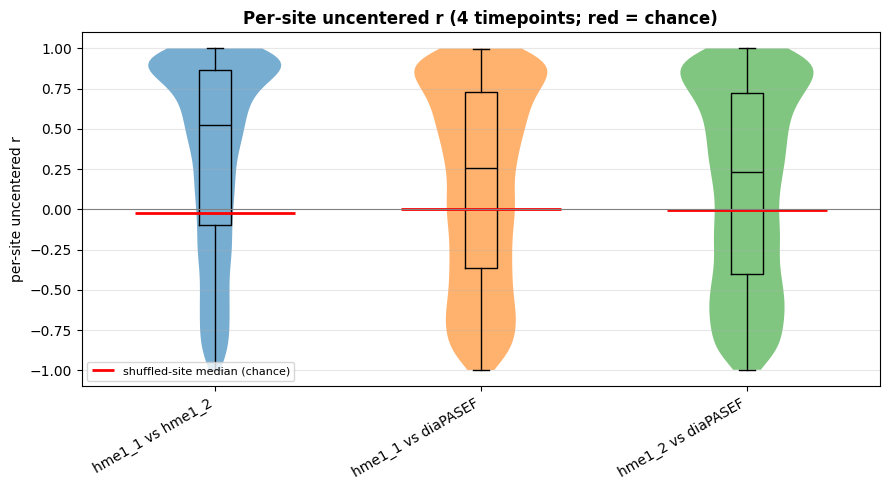

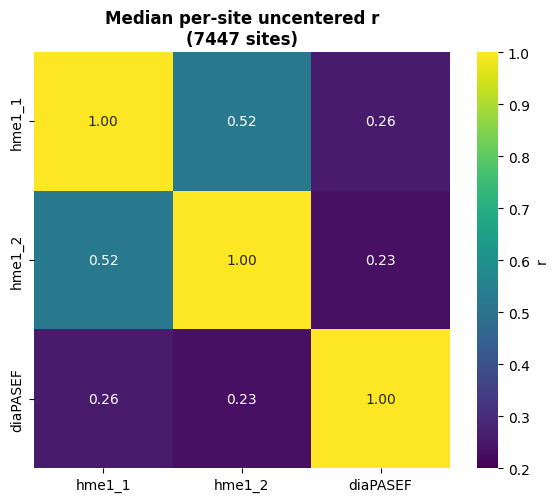

,pair,n_sites,median_r,iqr_low,iqr_high,null_median_r,null_p95,frac_above_null_p95
0,hme1_1 vs hme1_2,7447,0.525,-0.094,0.863,-0.023,0.918,0.165
1,hme1_1 vs diaPASEF,7447,0.257,-0.366,0.729,0.005,0.897,0.110
2,hme1_2 vs diaPASEF,7447,0.233,-0.401,0.723,-0.003,0.904,0.101


In [8]:
per_site = per_site_profile_correlation(profiles,
                                        method=PER_SITE_METHOD,)
null = per_site_profile_correlation(profiles,
                                    method=PER_SITE_METHOD,
                                    shuffle=True,
                                    seed=0,)
fig, site_summary = plot_per_site_distributions(per_site,
                                                null=null,
                                                title=f"Per-site {PER_SITE_METHOD} r ({len(TIMEPOINTS)} timepoints; red = chance)",
                                                save_path=out("02_per_site_with_null.png"),)
median_site_r = summarise_per_site_correlation(per_site,)
median_site_r.attrs["n_sites"] = N_SHARED
plot_correlation_heatmap(median_site_r,
                         title=f"Median per-site {PER_SITE_METHOD} r",
                         cluster=False,
                         figsize=(6, 5),
                         save_path=out("03_median_per_site_heatmap.png"),)
site_summary.round(3)

#### Reading this result (run of 2026-09-16, `CENTER = "median"`, 7,447 shared sites)

| pair | median r | chance (red bar) | `frac_above_null_p95` |
|---|---|---|---|
| hme1_1 vs hme1_2 | 0.53 | −0.02 | 0.17 |
| hme1_1 vs diaPASEF | 0.26 | 0.01 | 0.11 |
| hme1_2 vs diaPASEF | 0.23 | 0.00 | 0.10 |

- All chance levels are ≈ 0, so the medians can be compared directly.
- The two TMT experiments share site-level profile shapes about **twice as strongly** as either shares
  with diaPASEF. Dose (30-fold range) and platform are mixed in that difference and cannot be separated
  here.
- Even for the best pair, only 17% of sites beat the 95th percentile of random pairs (5% expected by
  chance), so for about 12% of sites more than chance the profile is recognisably shared. With 4
  timepoints, a lot of genuinely similar sites will not pass that bar either.

How to read the median per-site heatmap above: each cell is the median per-site r between two datasets (the black
line of the corresponding violin). Its chance level is ≈ 0 when `CENTER = "median"`, and not
otherwise (section 6).

These numbers change if the data or parameters change. Re-read the table after re-running.

## 3. Per-timepoint correlation

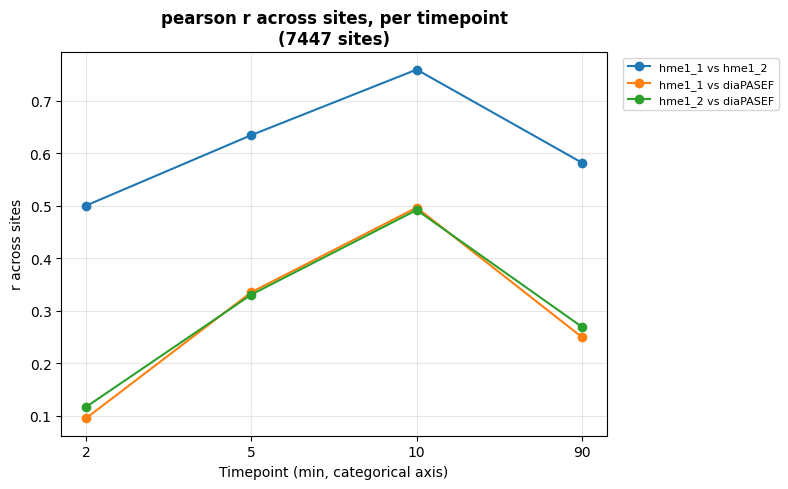

timepoint,2,5,10,90
pair,,,,
hme1_1 vs diaPASEF,0.095,0.335,0.496,0.250
hme1_1 vs hme1_2,0.500,0.634,0.759,0.582
hme1_2 vs diaPASEF,0.117,0.331,0.492,0.269


In [9]:
per_tp = per_timepoint_correlation(profiles,
                                   method=GLOBAL_METHOD,)
plot_per_timepoint_correlation(per_tp,
                               title=f"{GLOBAL_METHOD} r across sites, per timepoint",
                               save_path=out("04_per_timepoint.png"),)
per_tp.pivot(index="pair", columns="timepoint", values="r")[TIMEPOINTS].round(3)

## 4. Scatter — every pair, every timepoint

The dashed line is identity. TMT ratio compression shows up as a slope below 1 when a TMT dataset is
plotted against diaPASEF, and that affects the amplitude but not r.

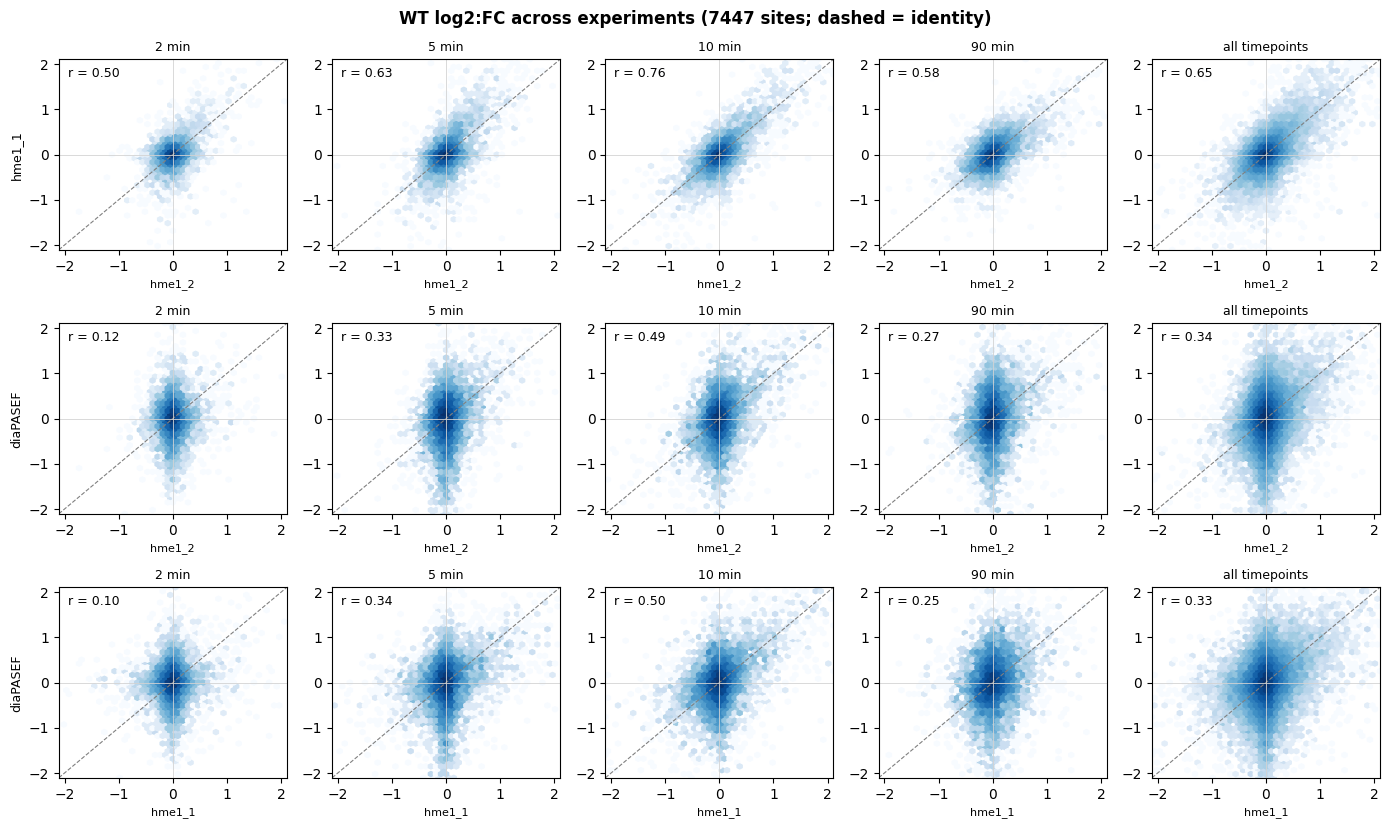

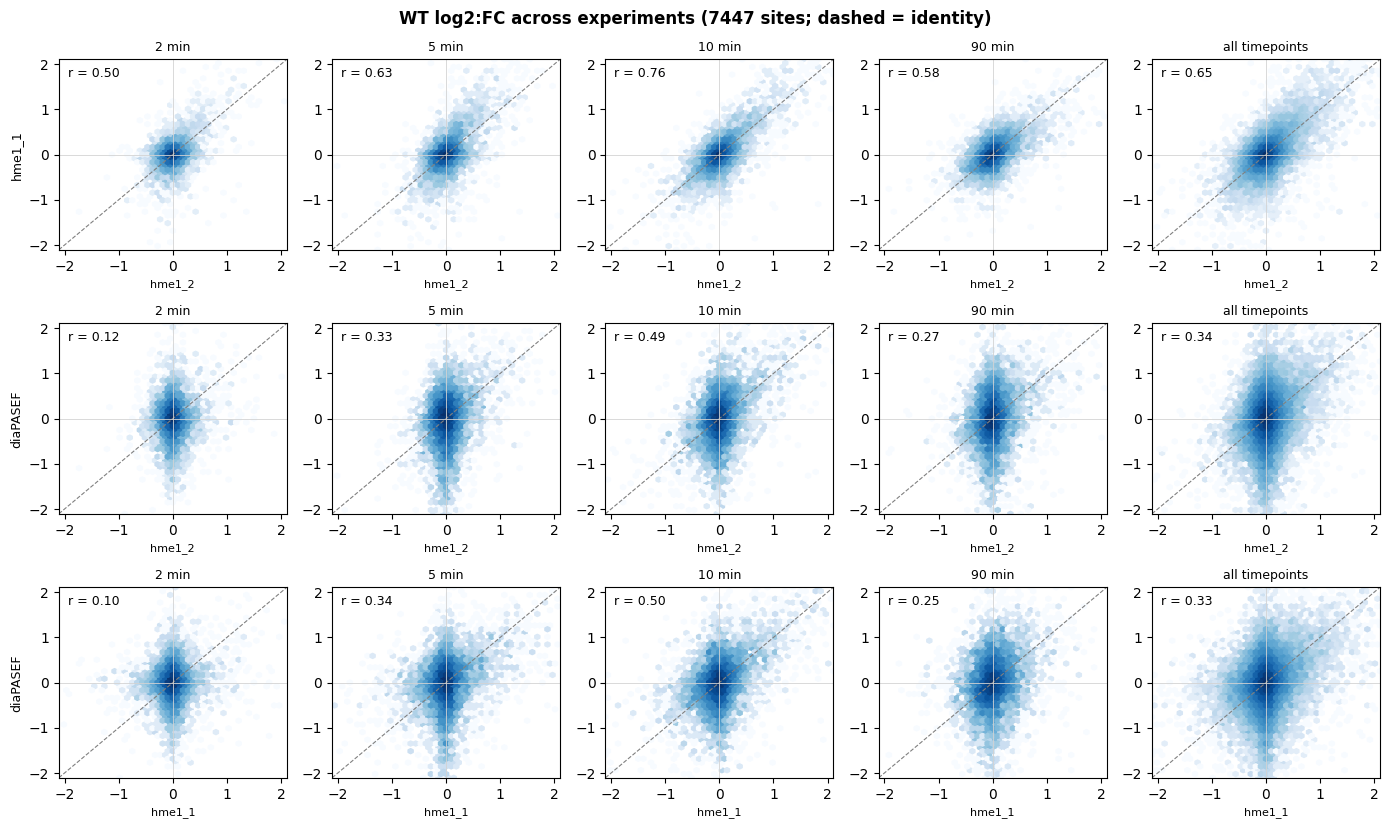

In [10]:
plot_profile_scatter_grid(profiles,
                          pairs=[("hme1_2", "hme1_1"), ("hme1_2", "diaPASEF"), ("hme1_1", "diaPASEF")],
                          by_timepoint=True,
                          title=f"WT {DATA_TYPE} across experiments",
                          save_path=out("05_scatter_pairs_by_timepoint.png"),)

## 5. Responsive sites only

Sites that limma's omnibus F calls EGF-responsive (FFDR < `MAX_FFDR`) in **at least one** dataset in
`RESPONSIVE_IN`, restricted to the same shared site set. Each dataset's FFDR comes from its own limma
fit on uncorrected values.

FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 4114 of 22010 sites kept (17896 dropped, of which 5706 never tested by limma)
FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 14964 of 33439 sites kept (18475 dropped, of which 9531 never tested by limma)
FFDR < 0.05 (any of WT_log2:FFDR_EGF_omnibus): 115 of 21793 sites kept (21678 dropped, of which 5669 never tested by limma)
5170 of 7447 shared sites are responsive in >= 1 of ['hme1_1', 'hme1_2', 'diaPASEF']


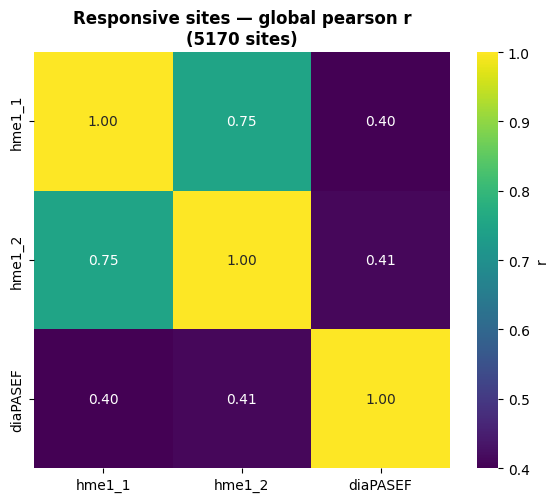

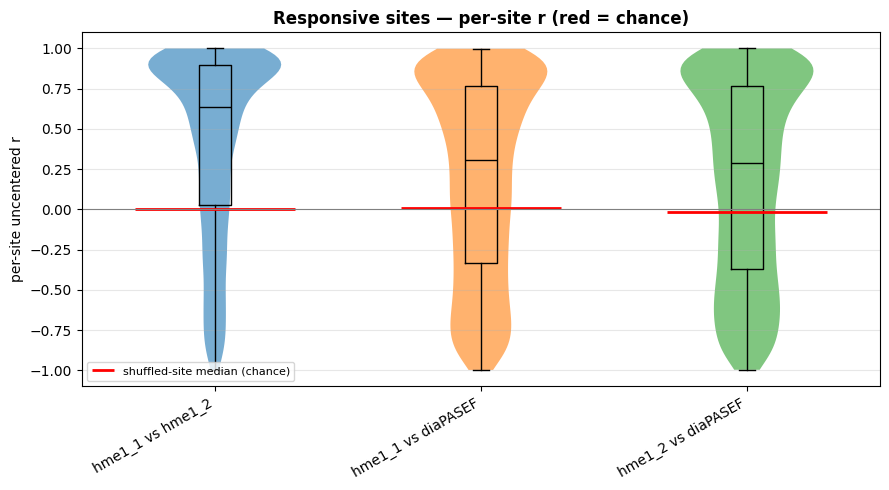

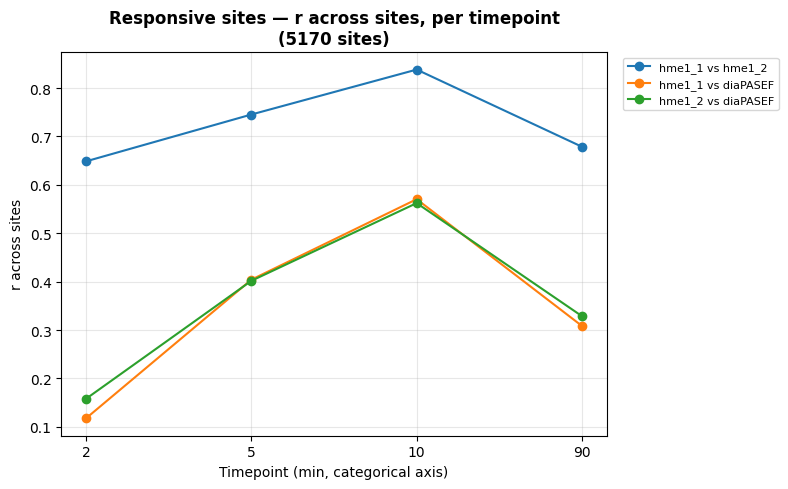

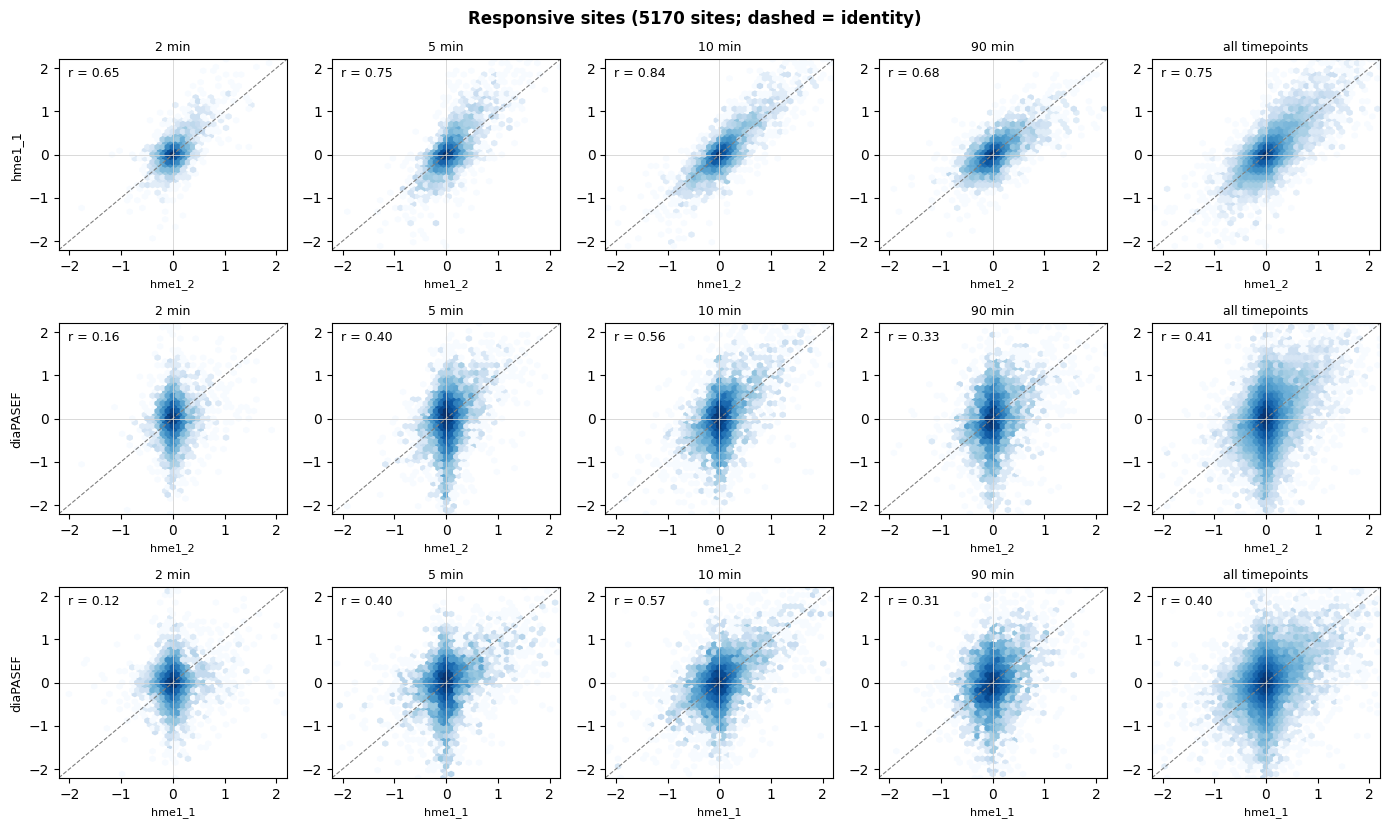

,hme1_1,hme1_2,diaPASEF
hme1_1,1.000,0.75,0.402
hme1_2,0.750,1.00,0.410
diaPASEF,0.402,0.41,1.000


,pair,n_sites,median_r,iqr_low,iqr_high,null_median_r,null_p95,frac_above_null_p95
0,hme1_1 vs hme1_2,5170,0.639,0.030,0.895,0.002,0.925,0.187
1,hme1_1 vs diaPASEF,5170,0.309,-0.330,0.765,0.009,0.906,0.120
2,hme1_2 vs diaPASEF,5170,0.285,-0.372,0.768,-0.018,0.910,0.117


In [11]:
if MAX_FFDR is not None:
    responsive_keys = set()
    for name in RESPONSIVE_IN:
        kept = filter_by_ffdr(keyed[name],
                              cell_lines=[CELL_LINE],
                              conditions=[f"_{CONDITION}_"],
                              max_ffdr=MAX_FFDR,
                              verbose=True,)
        responsive_keys |= set(kept.index)
    profiles_resp = {n: m.loc[m.index.isin(responsive_keys)] for n, m in profiles.items()}
    print(f"{len(profiles_resp['hme1_2'])} of {N_SHARED} shared sites are responsive in >= 1 of {RESPONSIVE_IN}")

    global_resp = global_profile_correlation(profiles_resp,
                                             method=GLOBAL_METHOD,)
    plot_correlation_heatmap(global_resp,
                             title=f"Responsive sites — global {GLOBAL_METHOD} r",
                             cluster=False,
                             figsize=(6, 5),
                             save_path=out("06_responsive_global_heatmap.png"),)
    fig, resp_summary = plot_per_site_distributions(per_site_profile_correlation(profiles_resp,
                                                                                 method=PER_SITE_METHOD,),
                                                    null=per_site_profile_correlation(profiles_resp,
                                                                                      method=PER_SITE_METHOD,
                                                                                      shuffle=True,),
                                                    title="Responsive sites — per-site r (red = chance)",
                                                    save_path=out("07_responsive_per_site_with_null.png"),)
    plot_per_timepoint_correlation(per_timepoint_correlation(profiles_resp,
                                                             method=GLOBAL_METHOD,),
                                   title="Responsive sites — r across sites, per timepoint",
                                   save_path=out("08_responsive_per_timepoint.png"),)
    plot_profile_scatter_grid(profiles_resp,
                              pairs=[("hme1_2", "hme1_1"), ("hme1_2", "diaPASEF"), ("hme1_1", "diaPASEF")],
                              by_timepoint=True,
                              title="Responsive sites",
                              save_path=out("09_responsive_scatter.png"),)
    display(global_resp.round(3))
    display(resp_summary.round(3))

#### Reading the responsive-site plots

The same reading applies: compare each violin's median with its red bar. Restricting to sites that
respond to EGF removes most of the flat, noise-only profiles, so the real medians rise (2026-09-16 run:
hme1_1 vs hme1_2 0.64, pairs with diaPASEF about 0.29–0.31). The chance level stays ≈ 0 here, unlike
in the diaPASEF notebook, because this subset (5,170 sites) is much larger and more varied in shape.

## 6. Sensitivity — the other centring setting

Sections 1–2 are repeated with the centring switched. The three datasets carry **different** shared
shifts (see the median table above). Per-timepoint r is unaffected by construction.

**Why the uncentred chance level is far from 0.** A shift shared by every site acts like an extra
common "profile" added to all of them. When two datasets have shifts pointing in opposite
directions (hme1_2 goes up at 5–10 min, diaPASEF goes down), every pair of sites looks
anti-correlated, even random ones. In the 2026-09-16 run: hme1_1 vs hme1_2 real median −0.40 with
chance −0.51; hme1_1 vs diaPASEF +0.79 with chance +0.72. Those uncentred medians describe the shifts,
not the sites. Only the gap to the red bar is interpretable, and it is small (≈ 0.05–0.11) because
the shift swamps the site-specific signal.

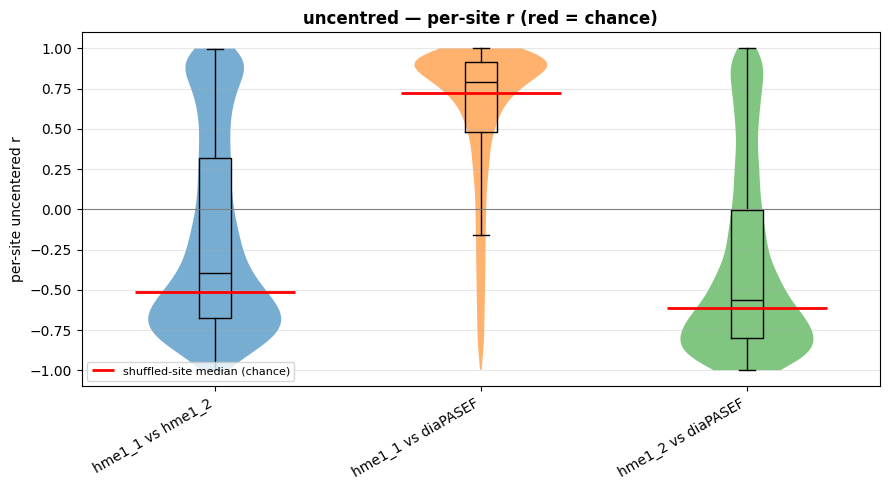

,pair,global_r (CENTER=median),global_r (uncentred),median_site_r (CENTER=median),null (CENTER=median),median_site_r (uncentred),null (uncentred)
0,hme1_1 vs hme1_2,0.648,0.605,0.525,-0.023,-0.398,-0.511
1,hme1_1 vs diaPASEF,0.334,0.331,0.257,0.005,0.791,0.723
2,hme1_2 vs diaPASEF,0.340,0.250,0.233,-0.003,-0.564,-0.616


In [12]:
profiles_c = profiles_raw if CENTER == "median" else profiles_centred
ALT_LABEL = "uncentred" if CENTER == "median" else "median-centred"
global_c = global_profile_correlation(profiles_c,
                                      method=GLOBAL_METHOD,)
per_site_c = per_site_profile_correlation(profiles_c,
                                          method=PER_SITE_METHOD,)
null_c = per_site_profile_correlation(profiles_c,
                                      method=PER_SITE_METHOD,
                                      shuffle=True,)
fig, centred_summary = plot_per_site_distributions(per_site_c,
                                                   null=null_c,
                                                   title=f"{ALT_LABEL} — per-site r (red = chance)",
                                                   save_path=out("10_centred_per_site_with_null.png"),)

pairs = site_summary["pair"]
comparison = pd.DataFrame({"pair": pairs,
                           f"global_r (CENTER={CENTER})": [global_r.loc[p.split(" vs ")[0], p.split(" vs ")[1]] for p in pairs],
                           f"global_r ({ALT_LABEL})": [global_c.loc[p.split(" vs ")[0], p.split(" vs ")[1]] for p in pairs],
                           f"median_site_r (CENTER={CENTER})": site_summary["median_r"].to_numpy(),
                           f"null (CENTER={CENTER})": site_summary["null_median_r"].to_numpy(),
                           f"median_site_r ({ALT_LABEL})": centred_summary["median_r"].to_numpy(),
                           f"null ({ALT_LABEL})": centred_summary["null_median_r"].to_numpy(),})
comparison.round(3)

## Notes on interpretation

- The comparison is restricted to sites **all three** experiments quantified, which favours abundant,
  well-behaved phosphopeptides. The r values describe that subset, not the whole phosphoproteome.
- A low cross-platform r does not mean "the biology differs". Dose (30×), ratio compression, FC
  normalisation (none in any of the three tables) and DIA missingness all enter it. hme1_1 vs hme1_2 is
  the within-platform reference against which the diaPASEF pairs should be read.
- Only 4 timepoints are shared: 15 min is missing from hme1_1, and 1, 20 and 30 min are not common to
  all three.